# 01c — Data Acquisition (QBUS3850 Option C)

**Source:** Yahoo Finance via `yfinance` (sole source — no FRED, EIA, LSE, ICE)
**Date range:** 2016-01-01 → 2026-01-01
**Output:** 16 raw per-ticker CSVs, one combined parquet, one combined CSV, 3 overview figures, a tracking-gap report

This notebook runs first. All subsequent notebooks read from `data/processed/prices.parquet`.

In [1]:
import subprocess
import sys
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

PROJECT_ROOT = Path("/Users/macbook/Desktop/_3850/Group-Assignment/3850.Group")
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
QUALITY_DIR   = PROJECT_ROOT / "data" / "quality"
FIGURES_DIR   = PROJECT_ROOT / "figures" / "01_acquisition"
LOG_PATH      = RAW_DIR / "_acquisition_log.csv"

for d in (RAW_DIR, PROCESSED_DIR, QUALITY_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

START = "2016-01-01"
END   = "2026-01-01"

TICKERS = {
    # Direct front-month futures (6)
    "WTI":    "CL=F",
    "Brent":  "BZ=F",
    "RBOB":   "RB=F",
    "HO":     "HO=F",
    "HH_NG":  "NG=F",
    "TTF":    "TTF=F",
    # ETF / equity instruments (6)
    "Carbon": "KRBN",
    "Coal":   "COAL",
    "U_Phys": "SRUUF",
    "U_Min":  "URA",
    "USOil":  "USO",
    "Energy": "XLE",
    # Auxiliary (4)
    "RF":     "^IRX",
    "Bench":  "^SPGSEN",
    "DXY":    "DX-Y.NYB",
    "VIX":    "^VIX",
}

COMMODITY_KEYS = [k for k in TICKERS if k not in ("RF", "Bench", "DXY", "VIX")]
AUXILIARY_KEYS = ["RF", "Bench", "DXY", "VIX"]

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "savefig.bbox": "tight",
})

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"{len(TICKERS)} tickers: {list(TICKERS.keys())}")


PROJECT_ROOT = /Users/macbook/Desktop/_3850/Group-Assignment/3850.Group
16 tickers: ['WTI', 'Brent', 'RBOB', 'HO', 'HH_NG', 'TTF', 'Carbon', 'Coal', 'U_Phys', 'U_Min', 'USOil', 'Energy', 'RF', 'Bench', 'DXY', 'VIX']


## Step 1: Download raw data

In [2]:
import time

STUB_COLUMNS = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

def _has_fresh_cache():
    if not LOG_PATH.exists():
        return False
    if datetime.fromtimestamp(LOG_PATH.stat().st_mtime) < datetime.now() - timedelta(hours=24):
        return False
    for name in TICKERS:
        if not (RAW_DIR / f"{name}.csv").exists():
            return False
    return True

def _load_one_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "Date"
    return df

def _split_multi(raw: pd.DataFrame, symbol: str) -> pd.DataFrame:
    if isinstance(raw.columns, pd.MultiIndex):
        if symbol in raw.columns.get_level_values(0):
            sub = raw[symbol].copy()
        elif symbol in raw.columns.get_level_values(1):
            sub = raw.xs(symbol, axis=1, level=1).copy()
        else:
            return pd.DataFrame()
    else:
        sub = raw.copy()
    sub = sub.dropna(how="all")
    return sub

def _retry_single(symbol: str) -> pd.DataFrame:
    try:
        h = yf.Ticker(symbol).history(start=START, end=END, auto_adjust=False)
    except Exception:
        return pd.DataFrame()
    if h is None or h.empty:
        return pd.DataFrame()
    if h.index.tz is not None:
        h.index = h.index.tz_localize(None)
    h.index.name = "Date"
    return h.dropna(how="all")

def _log_success(rows, name, symbol, sub):
    rows.append({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "friendly_name": name, "yahoo_symbol": symbol,
        "row_count": int(len(sub)),
        "first_date": str(sub.index.min().date()),
        "last_date":  str(sub.index.max().date()),
        "success": True, "error": "",
    })

def _log_failure(rows, name, symbol, err):
    rows.append({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "friendly_name": name, "yahoo_symbol": symbol,
        "row_count": 0, "first_date": "", "last_date": "",
        "success": False, "error": str(err),
    })

log_rows = []
raw_data: dict[str, pd.DataFrame] = {}

if _has_fresh_cache():
    for name in TICKERS:
        raw_data[name] = _load_one_csv(RAW_DIR / f"{name}.csv")
    print(f"[CACHE] Loaded {len(raw_data)} tickers from data/raw/")
else:
    symbols = list(TICKERS.values())
    print(f"[ACQUIRE] Downloading {len(symbols)} symbols from Yahoo Finance...")
    raw = yf.download(
        symbols, start=START, end=END,
        auto_adjust=False, progress=True, group_by="ticker",
    )
    failed_first_pass = []
    for name, symbol in TICKERS.items():
        try:
            sub = _split_multi(raw, symbol)
            if sub.empty:
                raise RuntimeError("empty dataframe returned in batched download")
            sub.to_csv(RAW_DIR / f"{name}.csv")
            raw_data[name] = sub
            _log_success(log_rows, name, symbol, sub)
        except Exception as exc:
            failed_first_pass.append((name, symbol, exc))

    if failed_first_pass:
        print(f"[RETRY] {len(failed_first_pass)} tickers empty in batch; retrying individually")
        time.sleep(5)
        for name, symbol, prior_err in failed_first_pass:
            sub = _retry_single(symbol)
            if not sub.empty:
                sub.to_csv(RAW_DIR / f"{name}.csv")
                raw_data[name] = sub
                _log_success(log_rows, name, symbol, sub)
                print(f"  [RETRY-OK] {name} ({symbol}): {len(sub)} rows")
            else:
                stub = pd.DataFrame(columns=STUB_COLUMNS)
                stub.index.name = "Date"
                stub.to_csv(RAW_DIR / f"{name}.csv")
                raw_data[name] = stub
                _log_failure(log_rows, name, symbol, prior_err)
                print(f"  [FAIL] {name} ({symbol}): {prior_err} (stub CSV written)")
            time.sleep(1)

    pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False)
    successes = sum(1 for r in log_rows if r["success"])
    print(f"[ACQUIRE] {successes} of {len(TICKERS)} tickers downloaded successfully")


[CACHE] Loaded 16 tickers from data/raw/


## Step 2: Summary table

In [3]:
def _price_col(df: pd.DataFrame) -> pd.Series:
    for col in ("Adj Close", "Close"):
        if col in df.columns:
            return df[col].dropna()
    return df.iloc[:, 0].dropna()

summary_rows = []
for name, symbol in TICKERS.items():
    df = raw_data.get(name)
    if df is None or df.empty:
        summary_rows.append({
            "name": name, "yahoo_symbol": symbol, "rows": 0,
            "start_date": pd.NaT, "end_date": pd.NaT,
            "pct_missing": np.nan, "last_close": np.nan, "inception_year": np.nan,
        })
        continue
    px = _price_col(df)
    start, end = px.index.min(), px.index.max()
    bdays = pd.bdate_range(start=start, end=end)
    pct_missing = float(1 - (len(px) / len(bdays))) if len(bdays) else np.nan
    summary_rows.append({
        "name": name,
        "yahoo_symbol": symbol,
        "rows": int(len(px)),
        "start_date": start.date(),
        "end_date": end.date(),
        "pct_missing": round(pct_missing, 4),
        "last_close": float(px.iloc[-1]),
        "inception_year": int(start.year),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(PROCESSED_DIR / "summary.csv", index=False)
print(summary_df.to_string(index=False))


  name yahoo_symbol  rows start_date   end_date  pct_missing  last_close  inception_year
   WTI         CL=F  2514 2016-01-04 2025-12-31       0.0360   57.419998          2016.0
 Brent         BZ=F  2515 2016-01-04 2025-12-31       0.0357   60.849998          2016.0
  RBOB         RB=F  2515 2016-01-04 2025-12-31       0.0357    1.705400          2016.0
    HO         HO=F  2515 2016-01-04 2025-12-31       0.0357    2.120600          2016.0
 HH_NG         NG=F  2515 2016-01-04 2025-12-31       0.0357    3.686000          2016.0
   TTF        TTF=F  2061 2017-10-23 2025-12-31       0.0360   28.160999          2017.0
Carbon         KRBN  1362 2020-07-31 2025-12-31       0.0368   35.400002          2020.0
  Coal         COAL   487 2024-01-24 2025-12-31       0.0375   22.809999          2024.0
U_Phys        SRUUF  1117 2021-07-22 2025-12-31       0.0371   19.468000          2021.0
 U_Min          URA  2514 2016-01-04 2025-12-31       0.0360   42.730000          2016.0
 USOil          USO  

## Step 3: Build processed combined dataset

In [4]:
bday_index = pd.bdate_range(start=START, end=END)
series_dict = {}
for name in TICKERS:
    df = raw_data.get(name)
    if df is None or df.empty:
        series_dict[name] = pd.Series(index=bday_index, dtype=float, name=name)
        continue
    px = _price_col(df)
    px.index = pd.to_datetime(px.index)
    px = px[~px.index.duplicated(keep="last")]
    aligned = px.reindex(bday_index)
    aligned = aligned.ffill(limit=5)
    aligned.name = name
    series_dict[name] = aligned

prices_wide = pd.concat(series_dict.values(), axis=1)
prices_wide.index.name = "Date"

prices_wide.to_parquet(PROCESSED_DIR / "prices.parquet", engine="pyarrow")
prices_wide.to_csv(PROCESSED_DIR / "prices.csv")

print(f"prices_wide shape : {prices_wide.shape}")
print(f"date range        : {prices_wide.index.min().date()} -> {prices_wide.index.max().date()}")
print("\nNaN count per column:")
print(prices_wide.isna().sum().to_string())


prices_wide shape : (2610, 16)
date range        : 2016-01-01 -> 2026-01-01

NaN count per column:
WTI          1
Brent        1
RBOB         1
HO           1
HH_NG        1
TTF        471
Carbon    1195
Coal      2103
U_Phys    1449
U_Min        1
USOil        1
Energy       1
RF           1
Bench     2610
DXY          1
VIX          1


## Step 4: Overview figures

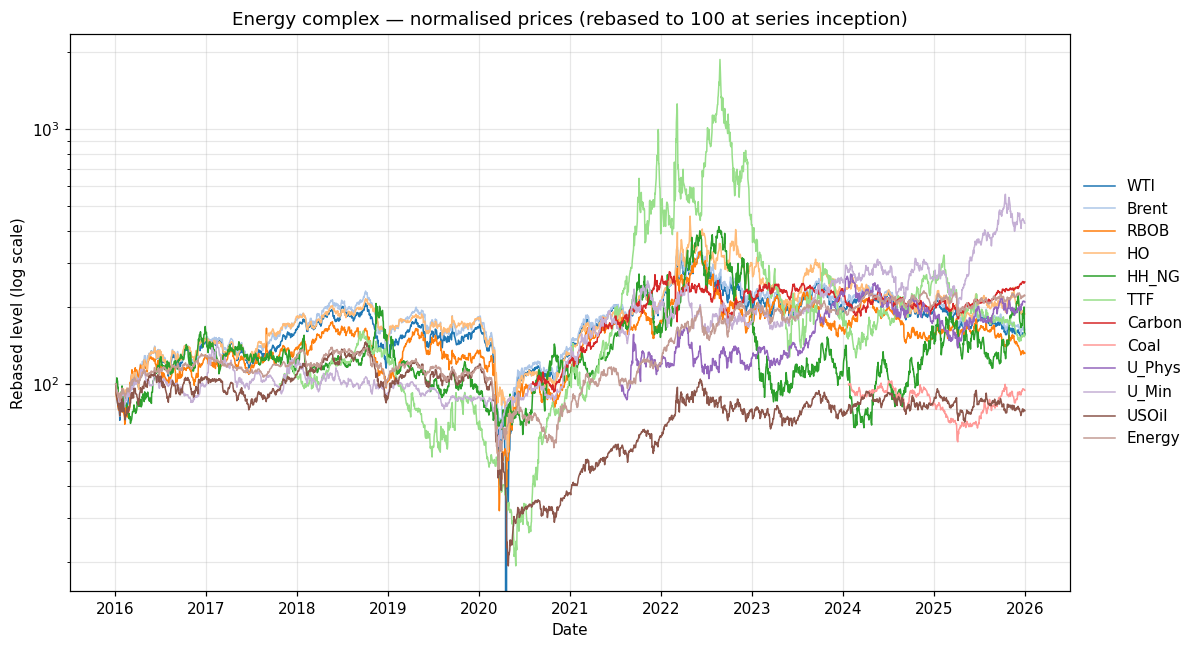

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.get_cmap("tab20")
for i, name in enumerate(COMMODITY_KEYS):
    s = prices_wide[name].dropna()
    if s.empty:
        continue
    rebased = 100 * s / s.iloc[0]
    ax.plot(rebased.index, rebased.values, label=name, lw=1.0, color=cmap(i % 20))
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Rebased level (log scale)")
ax.set_title("Energy complex — normalised prices (rebased to 100 at series inception)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_normalised_prices.png")
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


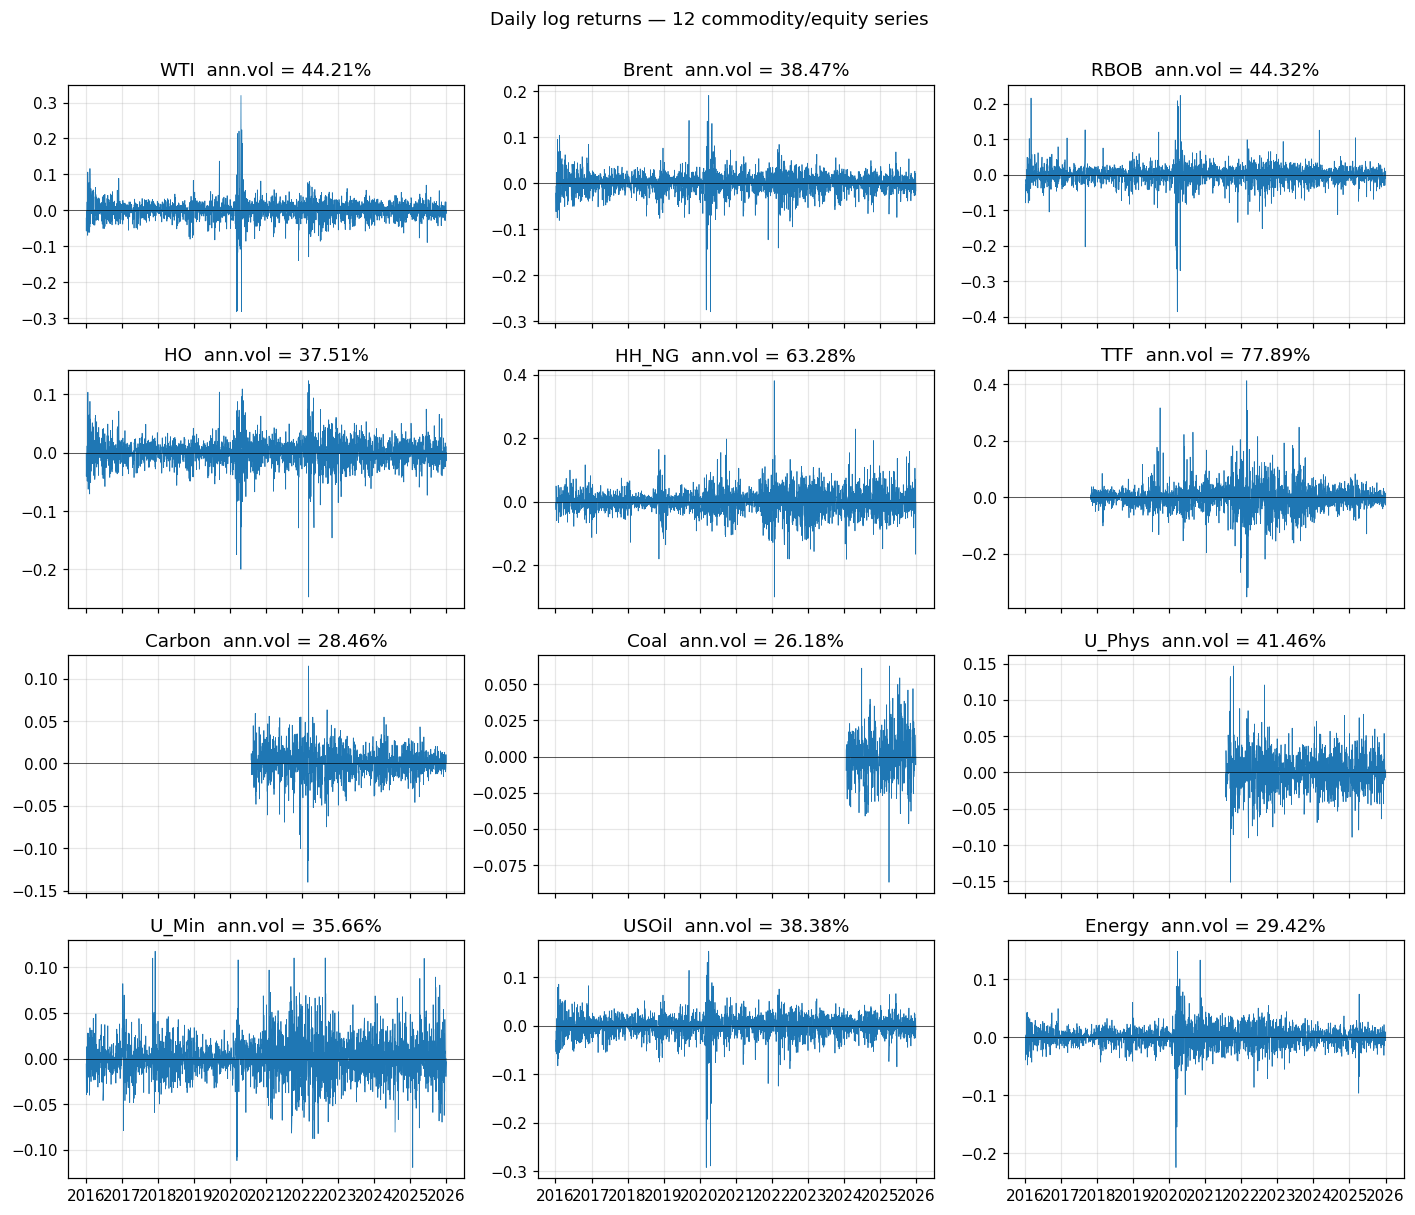

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(13, 11), sharex=True)
axes_flat = axes.flatten()
for ax, name in zip(axes_flat, COMMODITY_KEYS):
    s = prices_wide[name].dropna()
    if s.empty:
        ax.set_title(f"{name} — no data")
        ax.set_visible(False)
        continue
    rets = np.log(s).diff().dropna()
    ann_vol = float(rets.std() * np.sqrt(252))
    ax.plot(rets.index, rets.values, lw=0.5)
    ax.axhline(0, color="black", lw=0.4)
    ax.set_title(f"{name}  ann.vol = {ann_vol:.2%}")
    ax.grid(alpha=0.3)
for extra_ax in axes_flat[len(COMMODITY_KEYS):]:
    extra_ax.set_visible(False)
fig.suptitle("Daily log returns — 12 commodity/equity series", y=1.00)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_log_returns_small_multiples.png")
plt.show()


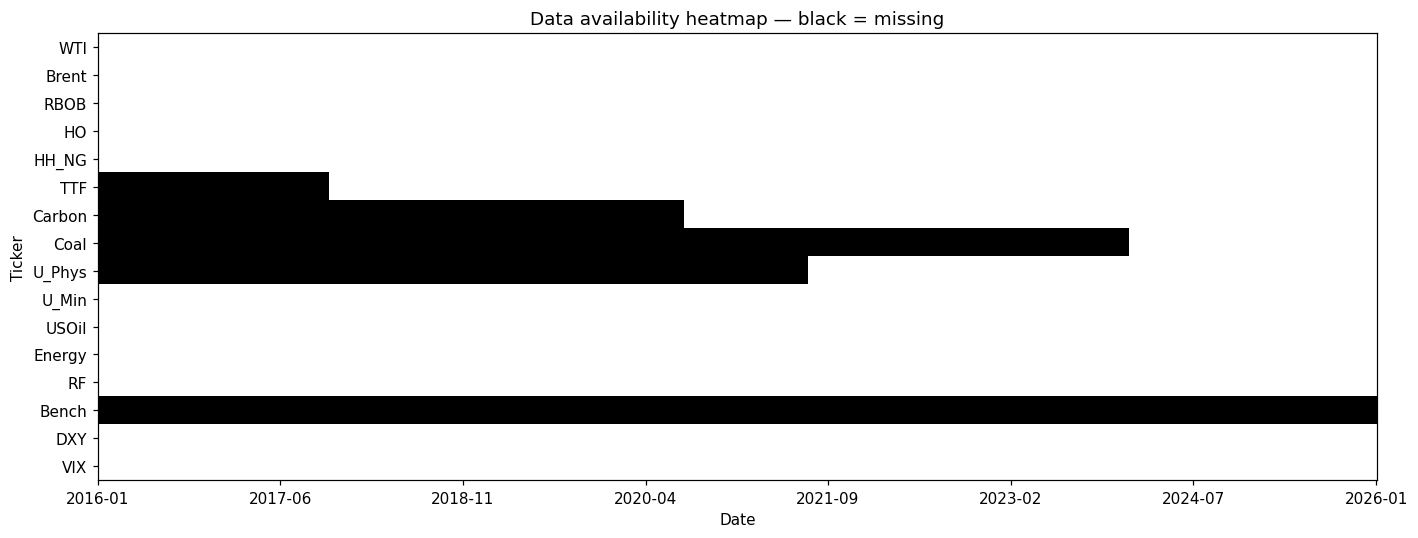

In [7]:
names = list(TICKERS.keys())
matrix = np.zeros((len(names), len(bday_index)), dtype=float)
for i, name in enumerate(names):
    s = prices_wide[name]
    matrix[i, :] = (~s.isna()).astype(float).values

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(matrix, aspect="auto", interpolation="nearest", cmap="gray",
          extent=[0, len(bday_index), len(names), 0], vmin=0, vmax=1)
tick_positions = np.linspace(0, len(bday_index) - 1, 8).astype(int)
tick_labels = [bday_index[t].strftime("%Y-%m") for t in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(np.arange(len(names)) + 0.5)
ax.set_yticklabels(names)
ax.set_xlabel("Date")
ax.set_ylabel("Ticker")
ax.set_title("Data availability heatmap — black = missing")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_missing_heatmap.png")
plt.show()


## Step 5: Run tracking-gap diagnostic

In [8]:
gap_path = QUALITY_DIR / "tracking_gap_report.csv"
gap_fresh = (
    gap_path.exists()
    and datetime.fromtimestamp(gap_path.stat().st_mtime)
        > datetime.now() - timedelta(hours=24)
)
if gap_fresh:
    print("[CACHE] tracking_gap_report.csv is fresh (<24h); skipping subprocess")
else:
    result = subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "scripts" / "data_quality.py")],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT),
    )
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)

if gap_path.exists():
    gap_report = pd.read_csv(gap_path)
    print(gap_report.to_string(index=False))
else:
    print("[WARN] tracking_gap_report.csv not produced")


[CACHE] tracking_gap_report.csv is fresh (<24h); skipping subprocess
 proxy proxy_symbol reference_symbol  n_obs  correlation  r_squared     beta  tracking_error_ann  mean_ann_diff  proxy_ann_return  proxy_ann_vol  ref_ann_return  ref_ann_vol
Carbon         KRBN             KEUA   1067     0.689106   0.474867 0.347066            0.423413       0.242465          0.051209       0.285088       -0.191256     0.566048
  Coal         COAL              KOL      0          NaN        NaN      NaN                 NaN            NaN               NaN            NaN             NaN          NaN
U_Phys        SRUUF              URA   1116     0.694689   0.482593 0.693273            0.330616      -0.052685          0.167570       0.422662        0.220255     0.423525
 U_Min          URA             URNM   1526     0.948639   0.899915 0.855640            0.145902      -0.009361          0.264014       0.411522        0.273375     0.456250


## Step 6: Acceptance check

In [9]:
checks = []

raw_csv_count = sum(1 for n in TICKERS if (RAW_DIR / f"{n}.csv").exists())
checks.append(("All 16 raw CSVs present", raw_csv_count == 16, f"{raw_csv_count}/16"))

pq = PROCESSED_DIR / "prices.parquet"
pq_ok = pq.exists()
pq_cols = pd.read_parquet(pq).shape[1] if pq_ok else 0
checks.append(("prices.parquet exists with 16 columns", pq_ok and pq_cols == 16, f"cols={pq_cols}"))

checks.append(("prices.csv exists", (PROCESSED_DIR / "prices.csv").exists(), ""))

fig_names = ["01_normalised_prices.png", "02_log_returns_small_multiples.png", "03_missing_heatmap.png"]
fig_ok = all((FIGURES_DIR / fn).exists() for fn in fig_names)
checks.append(("All 3 figures exist", fig_ok, ""))

gap_path = QUALITY_DIR / "tracking_gap_report.csv"
gap_rows = len(pd.read_csv(gap_path)) if gap_path.exists() else 0
checks.append(("tracking_gap_report.csv has >=1 row", gap_rows >= 1, f"rows={gap_rows}"))

sm = PROCESSED_DIR / "summary.csv"
checks.append(("summary.csv exists", sm.exists(), ""))

for label, passed, extra in checks:
    tag = "[OK]  " if passed else "[FAIL]"
    print(f"{tag} {label}" + (f"  ({extra})" if extra else ""))

print("\nDATA ACQUISITION COMPLETE")


[OK]   All 16 raw CSVs present  (16/16)
[OK]   prices.parquet exists with 16 columns  (cols=16)
[OK]   prices.csv exists
[OK]   All 3 figures exist
[OK]   tracking_gap_report.csv has >=1 row  (rows=4)
[OK]   summary.csv exists

DATA ACQUISITION COMPLETE
